In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
matches=pd.read_csv(r"D:\Cricket Data set\matches_2008-2024.csv")
deliveries=pd.read_csv(r"D:\Cricket Data set\deliveries_2008-2024.csv")

print(matches.head())
print(deliveries.shape)

       id  season        city        date match_type player_of_match  \
0  335982    2008   Bangalore  2008-04-18     League     BB McCullum   
1  335983    2008  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984    2008       Delhi  2008-04-19     League     MF Maharoof   
3  335985    2008      Mumbai  2008-04-20     League      MV Boucher   
4  335986    2008     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0        Kolkata Knig

In [3]:
print(matches.info())
print(matches.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   int64  
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [4]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [5]:
matches.dropna(subset=['winner'], inplace=True)
print("Cleaned data:", len(matches))

Cleaned data: 1090


In [6]:
team_wins=matches["winner"].value_counts()
print(team_wins)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


### 1. Toss wins == match wins

In [7]:
matches["toss_winner"] = matches["toss_winner"] == matches["winner"]
percetange=matches["toss_winner"].mean()*100
print("toss winners wins matches : ",percetange)

toss winners wins matches :  50.825688073394495


### 2. how much matches in season

In [8]:
season_matches=matches["season"].value_counts().sort_index()
print(season_matches)

season
2008    58
2009    57
2010    60
2011    72
2012    74
2013    76
2014    60
2015    57
2016    60
2017    59
2018    60
2019    59
2020    60
2021    60
2022    74
2023    73
2024    71
Name: count, dtype: int64


# deliveries

In [9]:
print(deliveries.columns)
print(deliveries.head())


Index(['match_id ', 'inning ', 'batting_team                ',
       'bowling_team                ', 'over ', 'ball ',
       'batter                  ', 'bowler                  ',
       'non_striker             ', 'batsman_runs ', 'extra_runs ',
       'total_runs ', 'extras_type ', 'is_wicket ', 'player_dismissed        ',
       'dismissal_kind        ', 'fielder'],
      dtype='object')
   match_id   inning   batting_team                  \
0     335982        1  Kolkata Knight Riders          
1     335982        1  Kolkata Knight Riders          
2     335982        1  Kolkata Knight Riders          
3     335982        1  Kolkata Knight Riders          
4     335982        1  Kolkata Knight Riders          

   bowling_team                  over   ball   batter                    \
0  Royal Challengers Bangalore       0      1  SC Ganguly                 
1  Royal Challengers Bangalore       0      2  BB McCullum                
2  Royal Challengers Bangalore       0      3  

In [10]:
print(deliveries.columns.sort_values())

Index(['ball ', 'batsman_runs ', 'batter                  ',
       'batting_team                ', 'bowler                  ',
       'bowling_team                ', 'dismissal_kind        ', 'extra_runs ',
       'extras_type ', 'fielder', 'inning ', 'is_wicket ', 'match_id ',
       'non_striker             ', 'over ', 'player_dismissed        ',
       'total_runs '],
      dtype='object')


In [11]:
deliveries.columns=deliveries.columns.str.strip()

In [12]:
top_batsman=deliveries.groupby("batter")["batsman_runs"].sum().head(10)
print(top_batsman)

batter
A Ashish Reddy              280
A Badoni                    634
A Chandila                    4
A Chopra                     53
A Choudhary                  25
A Dananjaya                   4
A Flintoff                   62
A Kamboj                      2
A Kumble                     35
A Manohar                   231
Name: batsman_runs, dtype: int64


In [18]:
top_bowlers=deliveries[deliveries['dismissal_kind'].isin(['caught','bowled','lbw','stumped','caught and bowled','hit wicket'])]
top_bowlers = top_bowlers.groupby('bowler')['player_dismissed'].count().head(10)
print(top_bowlers)

bowler
A Ashish Reddy               18
A Badoni                      2
A Chandila                   11
A Choudhary                   5
A Flintoff                    2
A Kamboj                      2
A Kumble                     45
A Mishra                    174
A Mithun                      7
A Nehra                     106
Name: player_dismissed, dtype: int64


In [17]:
print(deliveries['dismissal_kind'].unique())

['NA' 'caught' 'bowled' 'run out' 'lbw' 'retired hurt' 'stumped'
 'caught and bowled' 'hit wicket' 'obstructing the field' 'retired out']


In [16]:
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].str.strip()

In [19]:
matches.columns=matches.columns.str.strip()

### use numpy

In [20]:
season_runs=matches[['id','season']].merge(deliveries.groupby('match_id')['total_runs'].sum().reset_index(),
left_on='id', right_on='match_id')

season_total=season_runs.groupby('season')['total_runs'].sum()

print("Avg runs in season :",np.mean(season_total.values))
print("best seasin :",season_total.idxmax(), "-->", np.max(season_total.values))
print("best seasin :",season_total.idxmin(), "-->", np.min(season_total.values))

Avg runs in season : 20416.647058823528
best seasin : 2024 --> 25971
best seasin : 2009 --> 16353


In [22]:
toss_decision = matches['toss_decision'].value_counts()
print(toss_decision)

toss_decision
field    700
bat      390
Name: count, dtype: int64


In [23]:
potm = matches['player_of_match'].value_counts().head(10)
print(potm)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


In [26]:
sixes = deliveries[deliveries['batsman_runs'] == 6].groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)

In [37]:
print(deliveries['batter'].iloc[0])
print(repr(deliveries['batter'].iloc[0]))

SC Ganguly
'SC Ganguly'


In [38]:
print(deliveries[deliveries['batter'] == 'V Kohli']['batsman_runs'].sum())

8014


In [39]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().nlargest(10)
print(top_batsmen)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


array([[<Axes: title={'center': 'Most Wins - All Time'}, xlabel='Wins', ylabel='winner'>,
        <Axes: title={'center': 'Top 10 Run Scorers'}, xlabel='Runs', ylabel='batter'>],
       [<Axes: title={'center': 'Top 10 Wicket Takers'}, xlabel='Wickets', ylabel='bowler'>,
        <Axes: title={'center': 'Season Wise Total Runs'}, xlabel='Season'>],
       [<Axes: title={'center': 'Top 6 Hitters'}, ylabel='batter'>,
        <Axes: >]], dtype=object)

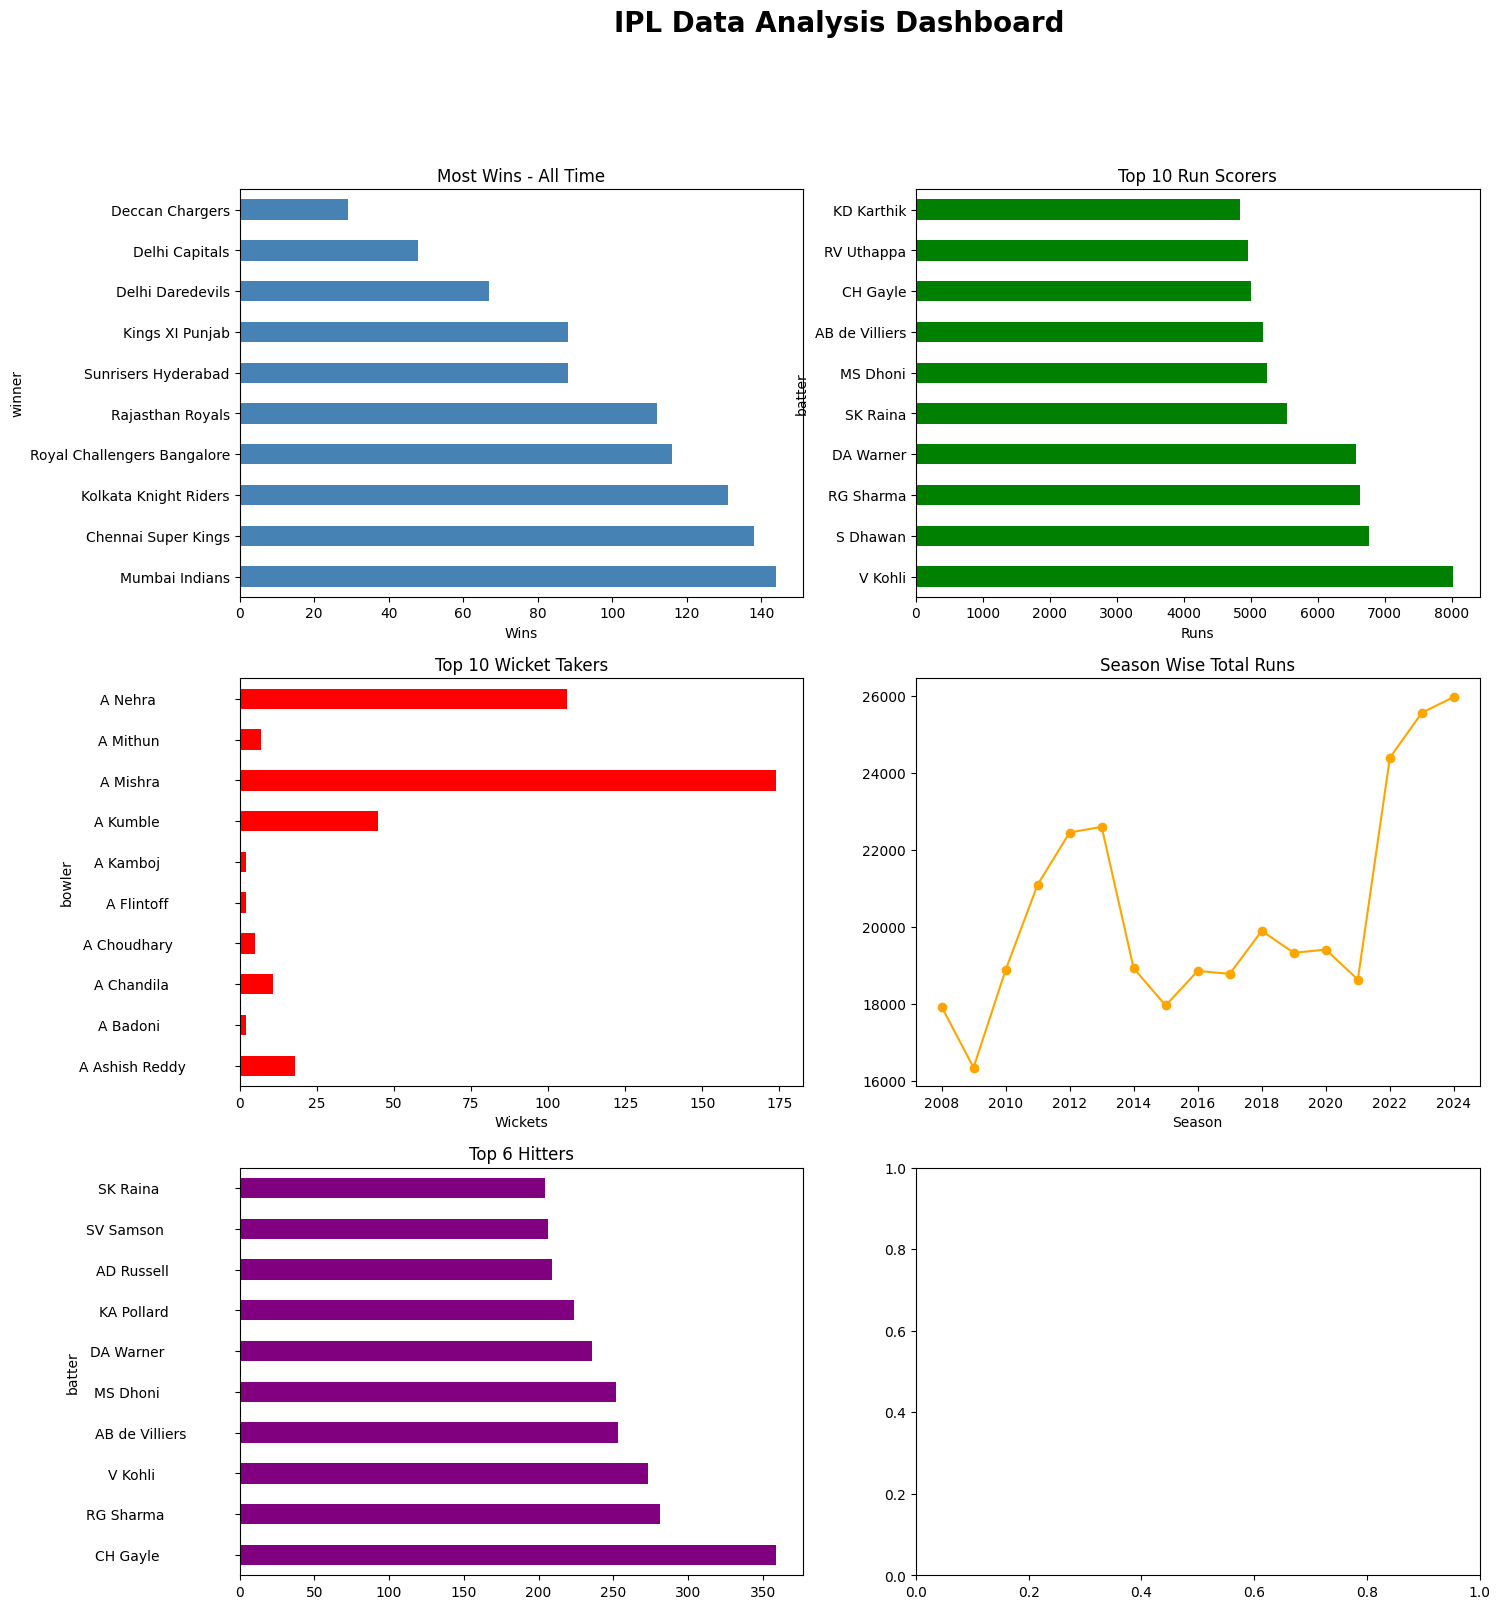

In [42]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('IPL Data Analysis Dashboard', fontsize=20, fontweight='bold')

team_wins.head(10).plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Most Wins - All Time')
axes[0,0].set_xlabel('Wins')

top_batsmen.plot(kind='barh', ax=axes[0,1], color='green')
axes[0,1].set_title('Top 10 Run Scorers')
axes[0,1].set_xlabel('Runs')

top_bowlers.plot(kind='barh', ax=axes[1,0], color='red')
axes[1,0].set_title('Top 10 Wicket Takers')
axes[1,0].set_xlabel('Wickets')

season_total.plot(kind='line', ax=axes[1,1], marker='o', color='orange')
axes[1,1].set_title('Season Wise Total Runs')
axes[1,1].set_xlabel('Season')

sixes.plot(kind='barh', ax=axes[2,0], color='purple')
axes[2,0].set_title('Top 6 Hitters')
axes

In [43]:
# Bowlers fix
deliveries['bowler'] = deliveries['bowler'].str.strip()
top_bowlers = deliveries[deliveries['dismissal_kind'].isin(['caught','bowled','lbw','stumped','caught and bowled','hit wicket'])].groupby('bowler')['player_dismissed'].count().nlargest(10)

# Player of match fix
matches['player_of_match'] = matches['player_of_match'].str.strip()
potm = matches['player_of_match'].value_counts().head(10)

print(top_bowlers)
print(potm)

bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
R Ashwin      180
SP Narine     180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
Name: player_dismissed, dtype: int64
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


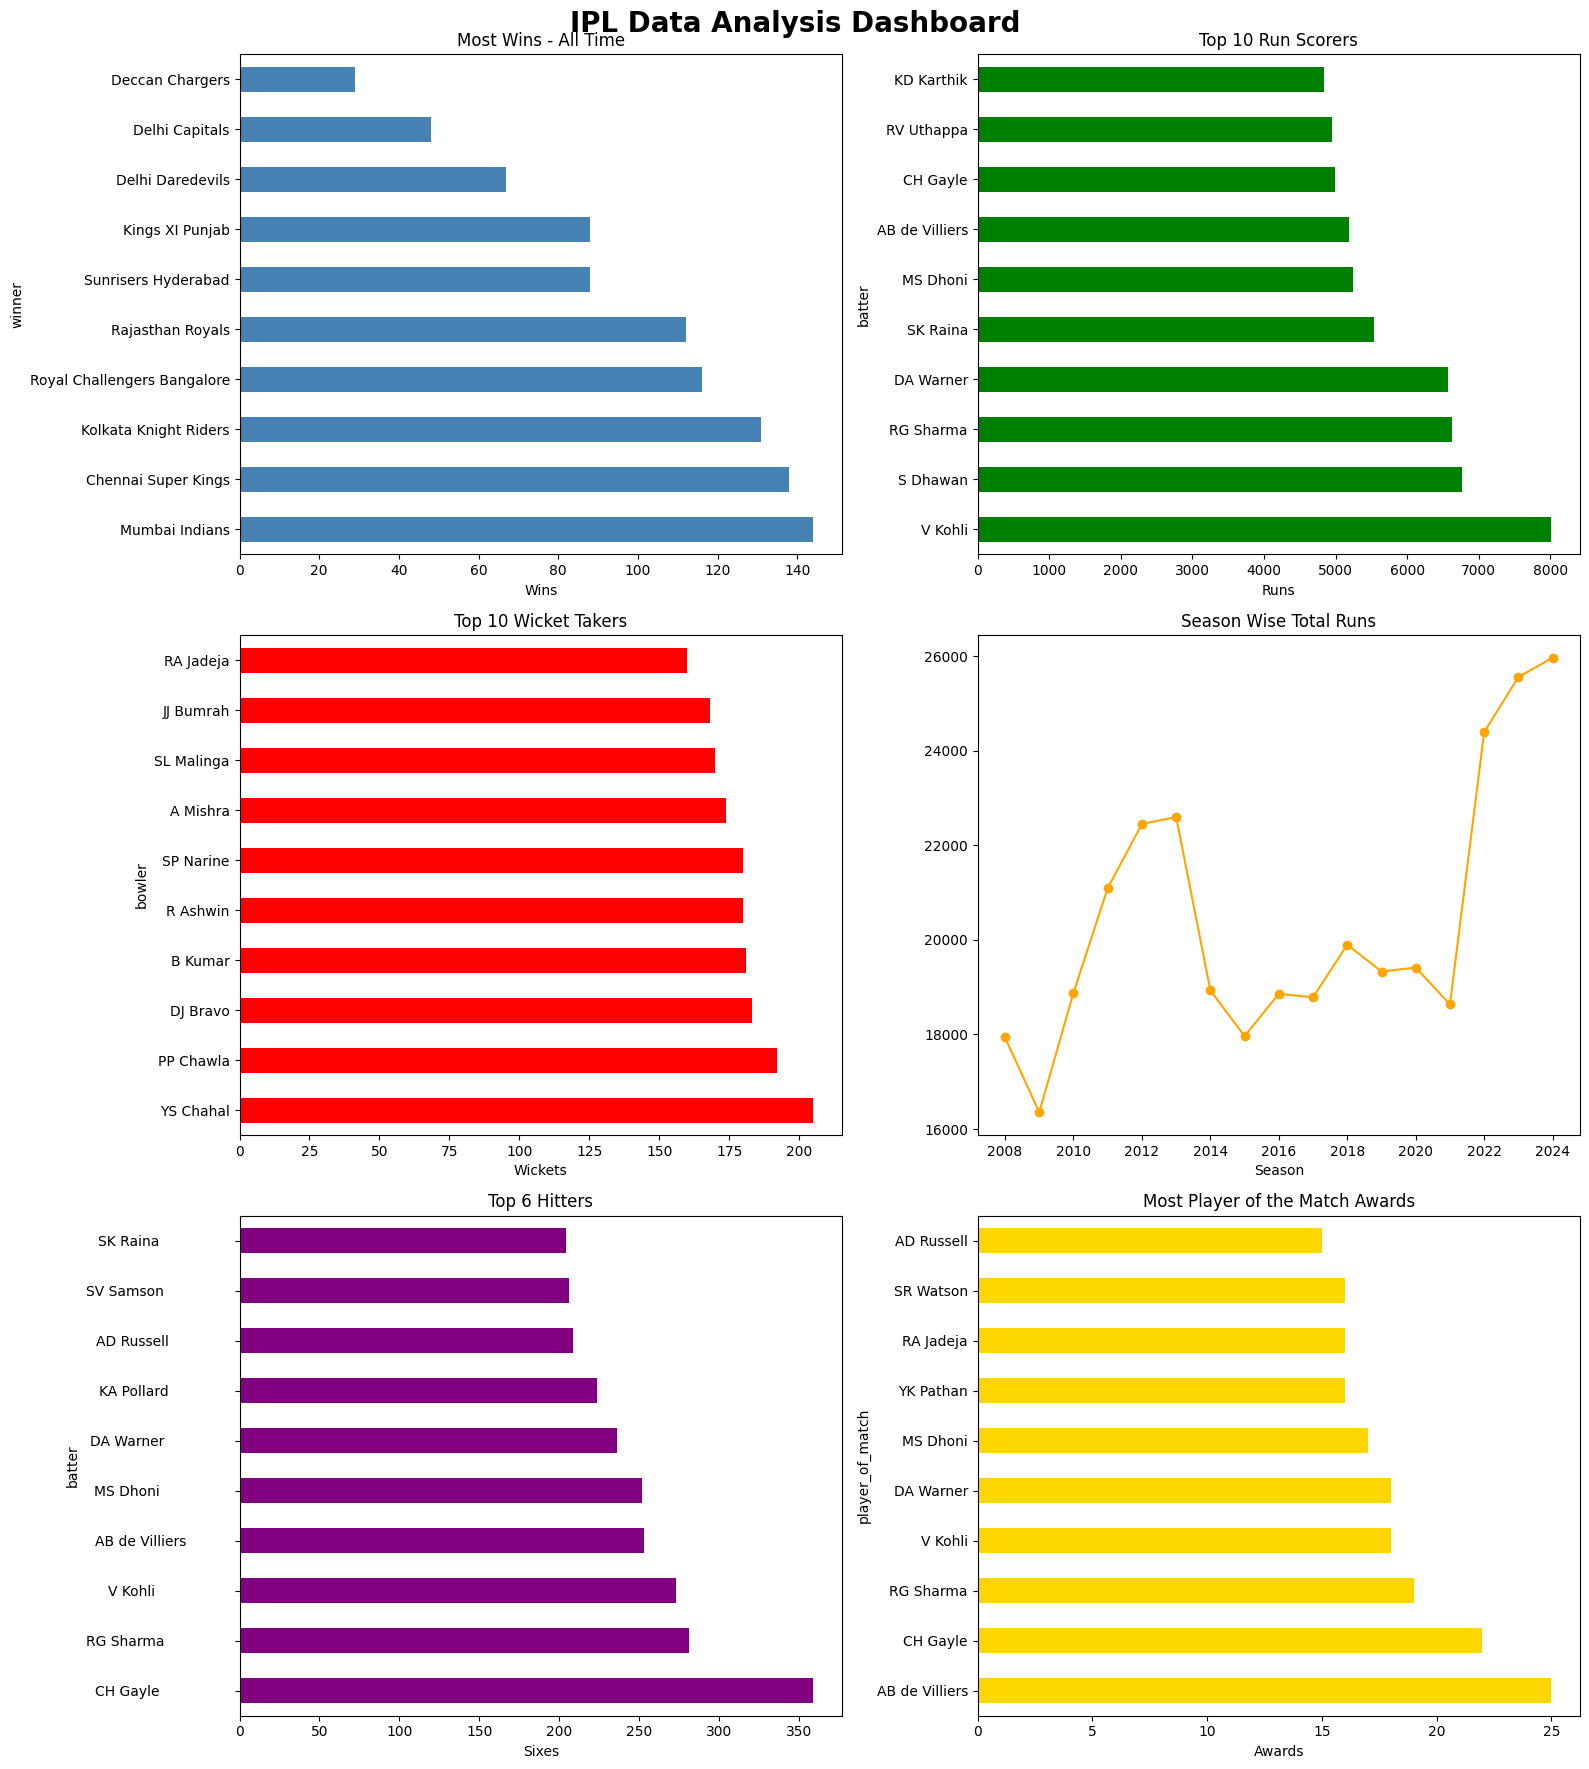

Dashboard save ho gaya!


In [44]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('IPL Data Analysis Dashboard', fontsize=20, fontweight='bold')

team_wins.head(10).plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Most Wins - All Time')
axes[0,0].set_xlabel('Wins')

top_batsmen.plot(kind='barh', ax=axes[0,1], color='green')
axes[0,1].set_title('Top 10 Run Scorers')
axes[0,1].set_xlabel('Runs')

top_bowlers.plot(kind='barh', ax=axes[1,0], color='red')
axes[1,0].set_title('Top 10 Wicket Takers')
axes[1,0].set_xlabel('Wickets')

season_total.plot(kind='line', ax=axes[1,1], marker='o', color='orange')
axes[1,1].set_title('Season Wise Total Runs')
axes[1,1].set_xlabel('Season')

sixes.plot(kind='barh', ax=axes[2,0], color='purple')
axes[2,0].set_title('Top 6 Hitters')
axes[2,0].set_xlabel('Sixes')

potm.plot(kind='barh', ax=axes[2,1], color='gold')
axes[2,1].set_title('Most Player of the Match Awards')
axes[2,1].set_xlabel('Awards')

plt.tight_layout()
plt.savefig('ipl_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard save ho gaya!")